# Sephora E-Commerce EDA: 01 - Data Overview & Quality Audit

This notebook provides a detailed inspection of the raw datasets, checking schemas, data dimensions, missingness patterns, and executing a **memory downcasting optimization pipeline** to handle our 1M+ reviews efficiently.

In [1]:
import sys
import os
# Add project root directory to python path
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from src.data_loader import load_products, load_reviews
from src.viz_utils import set_custom_style

# Configure default plotting aesthetics
set_custom_style()

Custom plotting style and palettes configured successfully.


## 1. Load Sephora Products Info

In [2]:
products_df = load_products("../data/product_info.csv")
products_df.head(5)

Loading products from ../data/product_info.csv...
Products shape: (8494, 27)
Memory: 12.95 MB -> 10.78 MB (Saved: 16.8%)


## 2. Load Reviews Dataset

We can selectively include review text. Let's load the reviews dataset without text first to check metadata features. Notice the optimized memory consumption printed by the loader.

In [3]:
reviews_df = load_reviews("../data", include_text=False)
reviews_df.head(5)

Found 5 review files. Loading sequentially...
Reviews shape: (1094411, 13)
Memory: 446.44 MB -> 96.48 MB (Saved: 78.4%)


Reading reviews CSVs: 100%|##########| 5/5 [00:04<00:00,  1.02it/s]


## 3. Data Schema and Types Audit

In [4]:
print("=== PRODUCTS DATA SCHEMA ===")
products_df.info()

print("\n" + "="*40 + "\n=== REVIEWS DATA SCHEMA ===")
reviews_df.info()

=== PRODUCTS DATA SCHEMA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   product_id          8494 non-null   object  
 1   product_name        8494 non-null   object  
 2   brand_id            8494 non-null   int64   
 3   brand_name          8494 non-null   object  
 4   loves_count         8494 non-null   int32   
 5   rating              8216 non-null   float32 
 6   reviews             8494 non-null   int32   
 7   size                8494 non-null   object  
 8   variation_type      8494 non-null   category
 9   variation_value     8494 non-null   object  
 10  variation_desc      8494 non-null   object  
 11  ingredients         8494 non-null   object  
 12  price_usd           8494 non-null   float32 
 13  value_price_usd     451 non-null    float32 
 14  sale_price_usd      270 non-null    float32 
 15  limited_e

## 4. Missing Values Analysis

Let's identify missing values across features using `missingno` to map missingness in our product catalog.

<string>:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


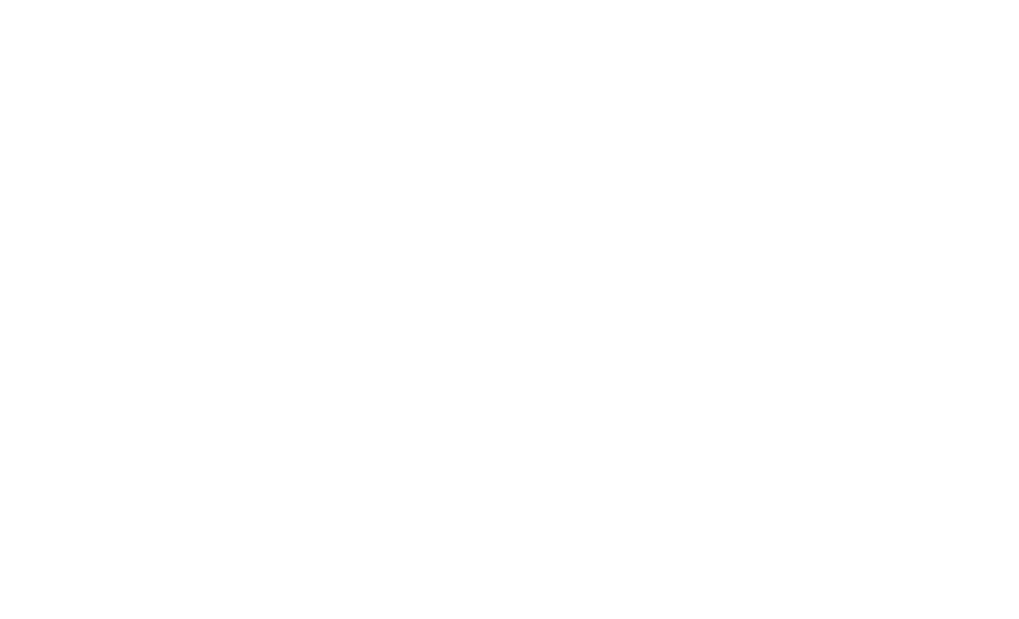

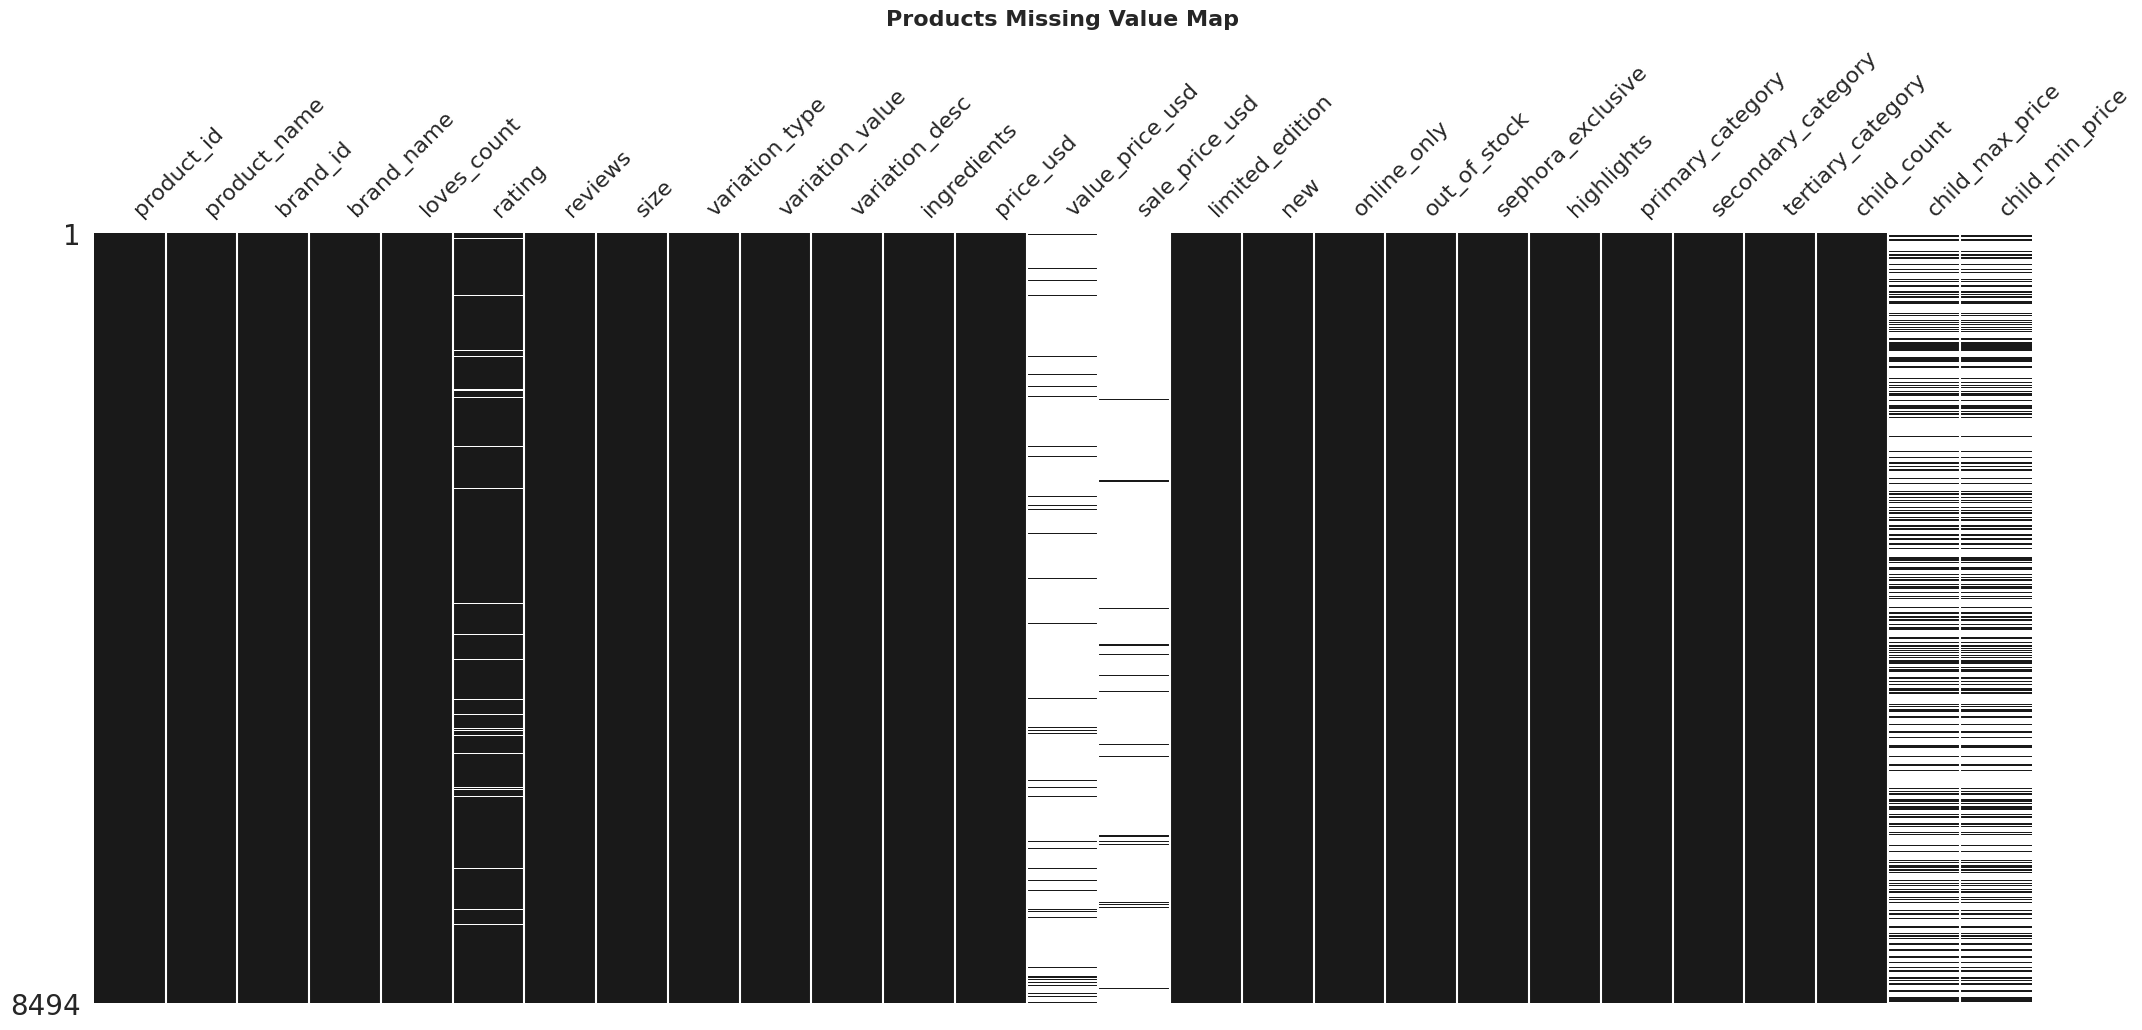

In [5]:
plt.figure(figsize=(10, 6))
msno.matrix(products_df, sparkline=False, color=(0.1, 0.1, 0.1))
plt.title("Products Missing Value Map", fontsize=16, pad=15)
plt.show()

## 5. Summary Statistics

In [6]:
print("=== PRODUCTS NUMERIC SUMMARY ===")
products_df.describe().T

print("\n=== REVIEWS NUMERIC SUMMARY ===")
reviews_df.describe().T

=== PRODUCTS NUMERIC SUMMARY ===
=== REVIEWS NUMERIC SUMMARY ===
